# Input-output properties cells

In [1]:
import numpy as np
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pwd

'/home/fernando/Dropbox/UEPG_DN/Ultra_Fast_Ripple/S1_opto_Thal'

In [3]:
# CircuitPath = 'O1_data_physiology/' # edges files not inclued in https://github.com/FernandoSBorges/NetPyNE_SONATA/tree/main/SCx_model/O1_data_physiology

CircuitPath = '/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/'
Atlas = CircuitPath + 'atlas/'
Atlas2 = 'O1_data_physiology/voxel_atlas_data/'
MorphologyPath = CircuitPath + 'morphologies/ascii/'
nrnPath = CircuitPath + 'S1nonbarrel_neurons__S1nonbarrel_neurons__chemical/edges.h5'
CellLibraryFile = CircuitPath + 'S1nonbarrel_neurons/nodes.h5'
METypePath = CircuitPath + 'emodels_hoc/'

lst_properties = [ 'etype', 'exc_mini_frequency', 'inh_mini_frequency', 'layer', 'me_combo', 'model_template', 'model_type', 'morph_class', 'morphology', 'mtype', 
                  'orientation_w', 'orientation_x', 'orientation_y', 'orientation_z', 'population', 'region', 'synapse_class', '@dynamics:holding_current', 
                  '@dynamics:input_resistance', '@dynamics:resting_potential', '@dynamics:threshold_current', 'x', 'y', 'z']

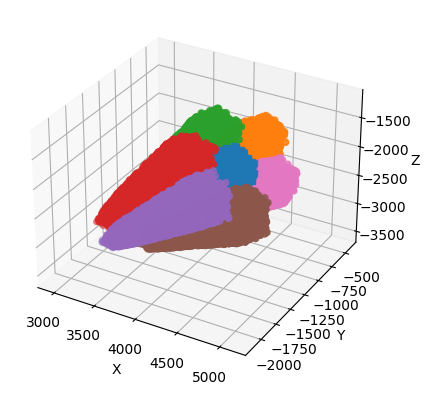

In [4]:
# pip install bluepysnap

In [5]:
from bluepysnap import Circuit
from bluepysnap.bbp import Cell
circuit_path = CircuitPath + 'circuit_config.json'
circuit = Circuit(circuit_path)

cells = circuit.nodes["S1nonbarrel_neurons"]
proj_cells = circuit.nodes["external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"]
cells_projections = proj_cells
nodesinfo = cells.get()
nodesinfo_projections = cells_projections.get()

In [6]:
nodesinfo[nodesinfo['mtype'] == 'L5_UPC'].head()

,etype,exc_mini_frequency,hexagon,inh_mini_frequency,layer,me_combo,model_template,model_type,morph_class,morphology,...,x,x_new,y,y_new,z,z_new,@dynamics:holding_current,@dynamics:input_resistance,@dynamics:resting_potential,@dynamics:threshold_current
node_ids,,,,,,,,,,,,,,,,,,,,,
175397,cADpyr,0.010108,4,0.233243,5,cADpyr_L5TPC_L5_UPC_5_dend-vd120112_idB_axon-v...,hoc:cADpyr_L5TPC,biophysical,PYR,dend-vd120112_idB_axon-vd130423_idB,...,3783.979592,1197.501656,-1726.950842,844.392074,-2621.002455,947.901133,-0.073128,96.699585,-78.179581,0.209156
175398,cADpyr,0.010108,1,0.233243,5,cADpyr_L5TPC_L5_UPC_5_dend-vd130423_idB_axon-F...,hoc:cADpyr_L5TPC,biophysical,PYR,dend-vd130423_idB_axon-Fluo15_right_-_Scale_x1...,...,3931.871542,37.637721,-568.664463,568.310246,-2346.674264,1079.239618,-0.056657,119.162033,-78.466377,0.171266
175399,cADpyr,0.010108,0,0.233243,5,cADpyr_L5TPC_L5_UPC_5_dend-rp110511_C1_idA_axo...,hoc:cADpyr_L5TPC,biophysical,PYR,dend-rp110511_C1_idA_axon-Fluo6_right_-_Scale_...,...,4000.858971,621.259451,-1187.016868,872.699325,-2564.674538,1042.144520,-0.047627,139.546387,-78.482635,0.137922
175400,cADpyr,0.010108,6,0.233243,5,cADpyr_L5TPC_L5_UPC_5_dend-rp101229_L5-1_idA_a...,hoc:cADpyr_L5TPC,biophysical,PYR,dend-rp101229_L5-1_idA_axon-rp110725_C2_idB_-_...,...,4051.578261,269.658907,-837.352989,908.497456,-2666.380189,940.769647,-0.051307,129.261276,-78.519058,0.154594
175401,cADpyr,0.010108,4,0.233243,5,cADpyr_L5TPC_L5_UPC_5_dend-rp110511_C1_idA_axo...,hoc:cADpyr_L5TPC,biophysical,PYR,dend-rp110511_C1_idA_axon-rp101213_L5-1_idC_-_...,...,4038.227764,931.110830,-1515.491111,981.329536,-2594.093027,1090.608972,-0.045801,141.744675,-78.627968,0.147016


In [7]:
# !nrnivmodl '/home/fernando/Dropbox/SCx_model/O1_data_physiology/mod/'

In [8]:
def distance3D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2)+np.power(nodesinfo['z'][gidpre]-nodesinfo['z'][gidpost],2))

def distance2D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2))

def distance2Dmean(gidpre, mean_x, mean_y):
    return np.sqrt(np.power(nodesinfo['x_new'][gidpre]-mean_x,2)+np.power(nodesinfo['y_new'][gidpre]-mean_y,2))

In [9]:
print(cells.property_values(Cell.REGION))

mtypes = sorted(cells.property_values(Cell.MTYPE))

i = 0
mntypes = {}
for mn in sorted(mtypes):
    mntypes[mn] = i
    i+=1

{'S1FL', 'S1DZ', 'S1J'}


## Select nodes to simulate

In [10]:
f = open('node_sets.json') 
node_sets = json.load(f) 

mean_x, mean_y = np.mean(nodesinfo['x_new']), np.mean(nodesinfo['y_new'])
node_gid = [] 
nodepremtype_new = []    
mtype_new = []     

hex = 'hex0'
# for gid in node_sets['hex0']['node_id']: 
#     if 'L1' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y)< 40.0:  
#         node_gid.append(gid)
#         nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#         if nodesinfo['mtype'][gid] not in mtype_new:
#             mtype_new.append(nodesinfo['mtype'][gid])

#         print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
        
# for gid in node_sets['hex0']['node_id']: 
#     if 'L23' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y)< 17.5:  
#         node_gid.append(gid)
#         nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#         if nodesinfo['mtype'][gid] not in mtype_new:
#             mtype_new.append(nodesinfo['mtype'][gid])

#         print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))

# for gid in node_sets['hex0']['node_id']: 
#     if 'L2_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y)< 7.5:  
#         node_gid.append(gid)
#         nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#         if nodesinfo['mtype'][gid] not in mtype_new:
#             mtype_new.append(nodesinfo['mtype'][gid])

#         print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))

# for gid in node_sets['hex0']['node_id']: 
#     if 'L3_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y)< 7.5:  
#         node_gid.append(gid)
#         nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#         if nodesinfo['mtype'][gid] not in mtype_new:
#             mtype_new.append(nodesinfo['mtype'][gid])

#         print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
     
            
for gid in node_sets['hex0']['node_id']: 
    if 'L4' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y)< 50.0 and 'EXC' in nodesinfo['synapse_class'][gid]:  
        node_gid.append(gid)
        nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
        if nodesinfo['mtype'][gid] not in mtype_new:
            mtype_new.append(nodesinfo['mtype'][gid])

        print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
           
for gid in node_sets['hex0']['node_id']: 
    if 'L4' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y)< 50.0 and 'INH' in nodesinfo['synapse_class'][gid]:  
        node_gid.append(gid)
        nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
        if nodesinfo['mtype'][gid] not in mtype_new:
            mtype_new.append(nodesinfo['mtype'][gid])

        print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
            
# for gid in node_sets['hex0']['node_id']: 
#     if 'L5' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y)< 7.5:  
#         node_gid.append(gid)
#         nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#         if nodesinfo['mtype'][gid] not in mtype_new:
#             mtype_new.append(nodesinfo['mtype'][gid])

#         print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
        
# for gid in node_sets['hex0']['node_id']: 
#     if 'L6' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y)< 7.5:  
#         node_gid.append(gid)
#         nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#         if nodesinfo['mtype'][gid] not in mtype_new:
#             mtype_new.append(nodesinfo['mtype'][gid])

#         print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))

# non central col

# for hex in node_sets['hex_O1']:
#     for gid in node_sets[hex]['node_id']:     
#         if 'L1_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 703.0 and distance2Dmean(gid, mean_x, mean_y) < 704.0:  
#             node_gid.append(gid)
#             nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#             if nodesinfo['mtype'][gid] not in mtype_new:
#                 mtype_new.append(nodesinfo['mtype'][gid])

#             print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))        
            
# for hex in node_sets['hex_O1']:
#     for gid in node_sets[hex]['node_id']:     
#         if 'L6_TPC' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 600.0 and distance2Dmean(gid, mean_x, mean_y) < 600.1:  
#             node_gid.append(gid)
#             nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#             if nodesinfo['mtype'][gid] not in mtype_new:
#                 mtype_new.append(nodesinfo['mtype'][gid])

#             print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))        

# mtype_new, distance3D(90290,96883), distance3D(90290,102178)

1 109126 L4_UPC hex0 7.651331885081482
2 109170 L4_UPC hex0 47.60050476436484
3 109310 L4_UPC hex0 34.48443084301747
4 109354 L4_UPC hex0 20.351223944318416
5 109439 L4_UPC hex0 45.295711055422984
6 109632 L4_UPC hex0 13.417897335385158
7 109685 L4_UPC hex0 44.2256476306792
8 109872 L4_UPC hex0 47.53859046134654
9 110044 L4_UPC hex0 25.026247274553242
10 110155 L4_UPC hex0 34.30680034096172
11 110359 L4_UPC hex0 41.69459180166744
12 110557 L4_UPC hex0 43.88019356917897
13 110595 L4_UPC hex0 28.61436220561171
14 110675 L4_UPC hex0 28.70631944021944
15 111043 L4_UPC hex0 45.193429651259066
16 111183 L4_UPC hex0 29.843177777414013
17 111324 L4_UPC hex0 30.971215472819594
18 111850 L4_UPC hex0 39.191418978677355
19 112199 L4_UPC hex0 42.843164554074434
20 112410 L4_UPC hex0 47.46245878719503
21 112417 L4_UPC hex0 49.92458640304773
22 112501 L4_UPC hex0 37.342237153852864
23 112531 L4_UPC hex0 13.071703743619349
24 112935 L4_UPC hex0 15.395198896427397
25 113007 L4_UPC hex0 38.3214032996177

# Exploring the Lists

In [11]:
hoclist = sorted(cells.property_values(Cell.MODEL_TEMPLATE))
Morpholist = sorted(cells.property_values(Cell.MORPHOLOGY))
Mtypelist = sorted(cells.property_values(Cell.MTYPE))
Mtypelist[0:3], hoclist[0:3], Morpholist[0:3]

(['L1_DAC', 'L1_HAC', 'L1_LAC'],
 ['hoc:bAC_L23BTC', 'hoc:bAC_L6BTC', 'hoc:bIR_L23BP'],
 ['C010306C', 'C010306C_-_Clone_0', 'C010306C_-_Clone_1'])

# NetPyNE

In [12]:
from netpyne import specs, sim   

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

In [13]:
cellName_list = {}
cellName_list2 = []
gid_list = {}


for gid in node_gid:

    cellName = nodesinfo['mtype'][gid] + '_' + nodesinfo['etype'][gid] + '_' + nodesinfo['region'][gid][:3]

    if cellName not in cellName_list2:
        cellName_list2 = []
        
    cellName_list2.append(cellName)
    
    cellName_list[gid] = cellName + '_' + str(len(cellName_list2)-1)
    gid_list[cellName + '_' + str(len(cellName_list2)-1)] = gid
    
    print('%s \t %d' % (cellName + '_' + str(len(cellName_list2)-1),gid))

L4_UPC_cADpyr_S1F_0 	 109126
L4_UPC_cADpyr_S1F_1 	 109170
L4_UPC_cADpyr_S1F_2 	 109310
L4_UPC_cADpyr_S1F_3 	 109354
L4_UPC_cADpyr_S1F_4 	 109439
L4_UPC_cADpyr_S1F_5 	 109632
L4_UPC_cADpyr_S1F_6 	 109685
L4_UPC_cADpyr_S1F_7 	 109872
L4_UPC_cADpyr_S1F_8 	 110044
L4_UPC_cADpyr_S1F_9 	 110155
L4_UPC_cADpyr_S1F_10 	 110359
L4_UPC_cADpyr_S1F_11 	 110557
L4_UPC_cADpyr_S1F_12 	 110595
L4_UPC_cADpyr_S1F_13 	 110675
L4_UPC_cADpyr_S1F_14 	 111043
L4_UPC_cADpyr_S1F_15 	 111183
L4_UPC_cADpyr_S1F_16 	 111324
L4_UPC_cADpyr_S1F_17 	 111850
L4_UPC_cADpyr_S1F_18 	 112199
L4_UPC_cADpyr_S1F_19 	 112410
L4_UPC_cADpyr_S1F_20 	 112417
L4_UPC_cADpyr_S1F_21 	 112501
L4_UPC_cADpyr_S1F_22 	 112531
L4_UPC_cADpyr_S1F_23 	 112935
L4_UPC_cADpyr_S1F_24 	 113007
L4_UPC_cADpyr_S1F_25 	 113019
L4_UPC_cADpyr_S1F_26 	 113129
L4_UPC_cADpyr_S1F_27 	 113207
L4_UPC_cADpyr_S1F_28 	 113318
L4_UPC_cADpyr_S1F_29 	 113319
L4_UPC_cADpyr_S1F_30 	 113402
L4_UPC_cADpyr_S1F_31 	 113596
L4_UPC_cADpyr_S1F_32 	 113680
L4_UPC_cADpyr_S1F_33

In [14]:
cellsList = {}

for cellName in sorted(gid_list.keys()):
    
    gid = gid_list[cellName]

    # MorphoName = nodesinfo['morphology'][gid] + '.asc'

    hocName = nodesinfo['model_template'][gid][4:]  

    MorphologyPath = '/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/morphologies2/ascii/'
    
    MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

    print(cellName,hocName)
        
    cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
        conds={'cellType': cellName, 'cellModel': 'HH_full'},
        fileName='/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/emodels_hoc/' + hocName + '.hoc',
        cellName=hocName,
        cellInstance = False,
        cellArgs=[gid, MorphologyPath, MorphoName])
    
    del netParams.cellParams[cellName]['secs']['myelin_0']
    del netParams.cellParams[cellName]['secs']['axon_0']
    del netParams.cellParams[cellName]['secs']['axon_1']

    cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
    # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]
    
# cellsList = {}

# for cellName in sorted(gid_list.keys()):
    
#     gid = gid_list[cellName]

#     # MorphoName = nodesinfo['morphology'][gid] + '.asc'

#     hocName = nodesinfo['model_template'][gid][4:]  

#     MorphologyPath = '/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/morphologies2/ascii/'
    
#     MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

#     print(cellName,hocName)
        
#     cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
#         conds={'cellType': cellName, 'cellModel': 'HH_full'},
#         fileName='/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/emodels_hoc2/' + hocName + '.hoc',
#         cellName=hocName,
#         cellInstance = False,
#         cellArgs=[gid, MorphologyPath, MorphoName])
    
#     # netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra'] = 2.0*netParams.cellParams[cellName]['secs']['axon_0']['geom']['Ra']

#     cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
#     # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]
    
# # cellsList


L4_LBC_cACint_S1F_0 cACint_L23MC
L4_LBC_dSTUT_S1F_0 dSTUT_L2SBC
L4_LBC_dSTUT_S1F_1 dSTUT_L2SBC
L4_MC_cACint_S1F_0 cACint_L23MC
L4_MC_cACint_S1F_1 cACint_L4CHC
L4_MC_cNAC_S1F_0 cNAC_L6BTC
L4_NBC_cNAC_S1F_0 cNAC_L6NGC
L4_NBC_cNAC_S1F_1 cNAC_L4CHC
L4_NBC_dNAC_S1F_0 dNAC_L23SBC
L4_NGC_cNAC_S1F_0 cNAC_L4CHC
L4_SBC_bNAC_S1F_0 bNAC_L23NGC
L4_SSC_cADpyr_S1F_0 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_1 cADpyr_L4TPC
L4_SSC_cADpyr_S1F_10 cADpyr_L4TPC
L4_SSC_cADpyr_S1F_11 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_12 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_13 cADpyr_L4TPC
L4_SSC_cADpyr_S1F_14 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_15 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_16 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_17 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_18 cADpyr_L4TPC
L4_SSC_cADpyr_S1F_19 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_2 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_20 cADpyr_L4TPC
L4_SSC_cADpyr_S1F_21 cADpyr_L4TPC
L4_SSC_cADpyr_S1F_22 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_3 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_4 cADpyr_L4UPC
L4_SSC_cADpyr_S1F_5 cADpyr_L4TPC
L4_SSC_cADpyr_S1F_6 cADpyr

In [15]:
# netParams.cellParams[cellName]
for cellName in netParams.cellParams.keys():    
    netParams.popParams[cellName] = {'cellType': cellName, 'cellsList': cellsList[cellName], 'cellModel': 'HH_full'}

In [16]:
netParams.popParams.keys()

odict_keys(['L4_LBC_cACint_S1F_0', 'L4_LBC_dSTUT_S1F_0', 'L4_LBC_dSTUT_S1F_1', 'L4_MC_cACint_S1F_0', 'L4_MC_cACint_S1F_1', 'L4_MC_cNAC_S1F_0', 'L4_NBC_cNAC_S1F_0', 'L4_NBC_cNAC_S1F_1', 'L4_NBC_dNAC_S1F_0', 'L4_NGC_cNAC_S1F_0', 'L4_SBC_bNAC_S1F_0', 'L4_SSC_cADpyr_S1F_0', 'L4_SSC_cADpyr_S1F_1', 'L4_SSC_cADpyr_S1F_10', 'L4_SSC_cADpyr_S1F_11', 'L4_SSC_cADpyr_S1F_12', 'L4_SSC_cADpyr_S1F_13', 'L4_SSC_cADpyr_S1F_14', 'L4_SSC_cADpyr_S1F_15', 'L4_SSC_cADpyr_S1F_16', 'L4_SSC_cADpyr_S1F_17', 'L4_SSC_cADpyr_S1F_18', 'L4_SSC_cADpyr_S1F_19', 'L4_SSC_cADpyr_S1F_2', 'L4_SSC_cADpyr_S1F_20', 'L4_SSC_cADpyr_S1F_21', 'L4_SSC_cADpyr_S1F_22', 'L4_SSC_cADpyr_S1F_3', 'L4_SSC_cADpyr_S1F_4', 'L4_SSC_cADpyr_S1F_5', 'L4_SSC_cADpyr_S1F_6', 'L4_SSC_cADpyr_S1F_7', 'L4_SSC_cADpyr_S1F_8', 'L4_SSC_cADpyr_S1F_9', 'L4_TPC_cADpyr_S1F_0', 'L4_TPC_cADpyr_S1F_1', 'L4_TPC_cADpyr_S1F_10', 'L4_TPC_cADpyr_S1F_100', 'L4_TPC_cADpyr_S1F_101', 'L4_TPC_cADpyr_S1F_102', 'L4_TPC_cADpyr_S1F_103', 'L4_TPC_cADpyr_S1F_104', 'L4_TPC_cADpyr_

## Net info

In [17]:
print(list(circuit.nodes))
print(list(circuit.edges))

['POm', 'S1nonbarrel_neurons', 'VPM', 'external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical']
['POm__S1nonbarrel_neurons__chemical', 'S1nonbarrel_neurons__S1nonbarrel_neurons__chemical', 'VPM__S1nonbarrel_neurons__chemical', 'external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical']


In [18]:
cells = circuit.nodes["S1nonbarrel_neurons"]
conn = circuit.edges["S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"]

proj_cells = circuit.nodes["external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"]
proj_conn = circuit.edges["external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"]
print(cells.size)
print(conn.size)
print(proj_cells.size)
# print(proj_conn.size)

211712
406836913
549126


### Synaptic connectivity

The synaptic connectivity of the model is accessed using circ_extr.edges.
As an example, let's find out which neurons innervate an exemplary neuron

In [19]:
var_list_a = ['@source_node','@target_node','conductance','conductance_scale_factor','decay_time','delay','depression_time',
                'facilitation_time','n_rrp_vesicles','spine_length','syn_type_id','u_hill_coefficient','u_syn', 
                'afferent_section_id', 'afferent_section_type', 'afferent_segment_id','efferent_section_id', 'efferent_section_type', 'efferent_segment_id']
list_pre = []

for gid2 in node_gid:
# afferent edges of node_ids[gid2]
    sampled_edge_ids = conn.afferent_edges(gid2)
    
    var_list_a = sorted(conn.property_names)
    
    connsinfo = conn.get(sampled_edge_ids,var_list_a)
    
    unique, counts = np.unique(list(connsinfo['@source_node'].values), return_counts=True)
    # unique, counts 
    synNumber = dict(zip(unique, counts))
    # synNumber
    
    for gid in node_gid:
        try:
            print("gid =",gid, cellName_list[gid], "\t coonected with \t gid =",gid2,cellName_list[gid2],'\t with',synNumber[gid], 'connections',
                  list([netParams.cellParams[cellName_list[gid]]['secLists']['all'][isecN] for isecN in connsinfo.get(connsinfo['@source_node']==gid)['efferent_section_id'].values]),
                  list([netParams.cellParams[cellName_list[gid2]]['secLists']['all'][isecN] for isecN in connsinfo.get(connsinfo['@source_node']==gid)['afferent_section_id'].values]))


            synType = connsinfo.get(connsinfo['@source_node']==gid)['syn_type_id'].values[0]

            if synType > 99:

                print("EXC -> gid =",gid, cellName_list[gid],"synType =",synType)

                netParams.synMechParams[cellName_list[gid]+'->'+cellName_list[gid2]] = {'mod': 'ProbAMPANMDA_EMS',
                                            'Dep': connsinfo.get(connsinfo['@source_node']==gid)['depression_time'].values[0],
                                            'Fac': connsinfo.get(connsinfo['@source_node']==gid)['facilitation_time'].values[0],
                                            'Use': connsinfo.get(connsinfo['@source_node']==gid)['u_syn'].values[0]/connsinfo.get(connsinfo['@source_node']==gid)['u_hill_coefficient'].values[0],
                                            'tau_d_AMPA': connsinfo.get(connsinfo['@source_node']==gid)['decay_time'].values[0],
                                            'NMDA_ratio':0.8,
                                            # 'Nrrp':connsinfo.get(connsinfo['@source_node']==gid)['n_rrp_vesicles'].values[0],
                                            }            
            else:

                print("INH -> gid =",gid, cellName_list[gid],"synType =",synType)                

                netParams.synMechParams[cellName_list[gid]+'->'+cellName_list[gid2]] = {'mod': 'ProbGABAAB_EMS',
                                            'Dep': connsinfo.get(connsinfo['@source_node']==gid)['depression_time'].values[0],
                                            'Fac': connsinfo.get(connsinfo['@source_node']==gid)['facilitation_time'].values[0],
                                            'Use': connsinfo.get(connsinfo['@source_node']==gid)['u_syn'].values[0]/connsinfo.get(connsinfo['@source_node']==gid)['u_hill_coefficient'].values[0],
                                            'tau_d_GABAA': connsinfo.get(connsinfo['@source_node']==gid)['decay_time'].values[0],
                                            'GABAB_ratio':0.0,
                                            # 'Nrrp':connsinfo.get(connsinfo['@source_node']==gid)['n_rrp_vesicles'].values[0], # new ProbGABAAB_EMS.mod not working, using 2015 version without 'Nrrp'
                                            }
                
            print(netParams.synMechParams[cellName_list[gid]+'->'+cellName_list[gid2]])


            netParams.connParams[cellName_list[gid]+'->'+cellName_list[gid2]] = { 
                        'preConds': {'pop': cellName_list[gid]},
                        'postConds': {'pop': cellName_list[gid2]},
                        'connList': [[0,0] for ii in range(len(connsinfo.get(connsinfo['@source_node']==gid)))],
                        'sec': list([netParams.cellParams[cellName_list[gid2]]['secLists']['all'][isecN] for isecN in connsinfo.get(connsinfo['@source_node']==gid)['afferent_section_id'].values]),                  # target postsyn section
                        'synMech': cellName_list[gid]+'->'+cellName_list[gid2],              # target synaptic mechanism
                        'weight': list(1.0*connsinfo.get(connsinfo['@source_node']==gid)['conductance'].values*connsinfo.get(connsinfo['@source_node']==gid)['conductance_scale_factor'].values[0]),                 # synaptic weight 
                        'delay':list(connsinfo.get(connsinfo['@source_node']==gid)['delay'].values),                 # synaptic delay 
                        # 'loc':list(connsinfo.get(connsinfo['@source_node']==gid)['afferent_section_pos'].values), # error only to plotShape syn positions
                        }    
                
            print(netParams.connParams[cellName_list[gid]+'->'+cellName_list[gid2]]) 
            
            if gid not in list_pre:
                list_pre.append(gid)
                
            print(connsinfo.get(connsinfo['@source_node']==gid)['conductance'].values[0],connsinfo.get(connsinfo['@source_node']==gid)['conductance_scale_factor'].values[0],
                  connsinfo.get(connsinfo['@source_node']==gid)['u_syn'].values[0],connsinfo.get(connsinfo['@source_node']==gid)['u_hill_coefficient'].values[0],
                  connsinfo.get(connsinfo['@source_node']==gid)['depression_time'].values[0],connsinfo.get(connsinfo['@source_node']==gid)['facilitation_time'].values[0],
                  connsinfo.get(connsinfo['@source_node']==gid)['decay_time'].values[0],connsinfo.get(connsinfo['@source_node']==gid)['n_rrp_vesicles'].values[0],
                  )
            print()
        except:
            pass #print(gid,cellName_list[gid], "\tnot coonected with \t gid =",gid2,cellName_list[gid2])

gid = 138475 L4_NBC_dNAC_S1F_0 	 coonected with 	 gid = 109126 L4_UPC_cADpyr_S1F_0 	 with 1 connections ['soma_0'] ['soma_0']
INH -> gid = 138475 L4_NBC_dNAC_S1F_0 synType = 0
{'mod': 'ProbGABAAB_EMS', 'Dep': 831.642578125, 'Fac': 16.211437225341797, 'Use': 0.0825375088096894, 'tau_d_GABAA': 8.745194435119629, 'GABAB_ratio': 0.0}
{'preConds': {'pop': 'L4_NBC_dNAC_S1F_0'}, 'postConds': {'pop': 'L4_UPC_cADpyr_S1F_0'}, 'connList': [[0, 0]], 'sec': ['soma_0'], 'synMech': 'L4_NBC_dNAC_S1F_0->L4_UPC_cADpyr_S1F_0', 'weight': [0.0], 'delay': [0.78062725]}
2.966592311859131 0.0 0.16012276709079742 1.94 831.642578125 16.211437225341797 8.745194435119629 5

gid = 142352 L4_LBC_cACint_S1F_0 	 coonected with 	 gid = 109170 L4_UPC_cADpyr_S1F_1 	 with 4 connections ['soma_0', 'soma_0', 'soma_0', 'soma_0'] ['soma_0', 'soma_0', 'soma_0', 'soma_0']
INH -> gid = 142352 L4_LBC_cACint_S1F_0 synType = 0
{'mod': 'ProbGABAAB_EMS', 'Dep': 1119.176513671875, 'Fac': 25.666275024414062, 'Use': 0.07048547267913818

In [20]:
var_list_a = ['@source_node','@target_node',
            #   'conductance','conductance_scale_factor','decay_time','delay','depression_time',
                # 'facilitation_time','n_rrp_vesicles','spine_length','syn_type_id','u_hill_coefficient','u_syn', 
                'afferent_section_id', 'afferent_section_type', 'afferent_segment_id','efferent_section_id', 'efferent_section_type', 'efferent_segment_id']

gid = 169225
gid2 = 205580
# afferent edges of node_ids[gid2]
sampled_edge_ids = conn.afferent_edges(gid2)    
# var_list_a = sorted(conn.property_names)[0:12]    
connsinfo = conn.get(sampled_edge_ids,var_list_a)
connsinfo.get(connsinfo['@source_node']==gid)

,@source_node,@target_node,afferent_section_id,afferent_section_type,afferent_segment_id,efferent_section_id,efferent_section_type,efferent_segment_id
384503103,169225,205580,289,4,15,33,2,37
384503104,169225,205580,306,4,70,68,2,44
384503105,169225,205580,289,4,1,73,2,13
384503106,169225,205580,328,4,26,77,2,0
384503107,169225,205580,328,4,25,80,2,0


In [21]:
# list_pre

In [22]:
# for gid in list_pre:
# for gid in node_gid[0:200]:

#     popName1 = cellName_list[gid]
#     current1 = 1.5*cells.get(gid,['@dynamics:threshold_current']).values[0]
#     holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]

#     netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 0.0, 'dur': 1500.0, 'amp': holding_current1}
#     netParams.stimSourceParams['Inputb_'+str(gid)] = {'type': 'IClamp', 'del': 300.0, 'dur': 1000.0, 'amp':current1}

#     netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}
#     netParams.stimTargetParams['Inputb->'+str(gid)] = {'source': 'Inputb_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

for gid in node_gid[59:]:

    popName1 = cellName_list[gid]
    current1 = 1.5*cells.get(gid,['@dynamics:threshold_current']).values[0]
    holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]

    netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 0.0, 'dur': 1500.0, 'amp': holding_current1-0.1}
    netParams.stimSourceParams['Inputb_'+str(gid)] = {'type': 'IClamp', 'del': 300.0, 'dur': 1000.0, 'amp':current1}

    netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}
    netParams.stimTargetParams['Inputb->'+str(gid)] = {'source': 'Inputb_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

In [23]:
#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 420.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 500.0 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 420.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
   

In [24]:
#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 0.5*1e1 ## Duration of the sim, in ms  
cfg.dt = 0.05
cfg.seeds = {'conn': 4321, 'stim': 1000, 'loc': 4321} 
cfg.hParams = {'celsius': 34, 'v_init': -74.0}  
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True  
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording 
#--------------------------------------------------------------------------
# cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'}}  ## Dict with traces to record  
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_axon_2': {'sec':'axon_2', 'loc':0.5, 'var':'v'},
                    # 'V_axon_15': {'sec':'axon_15', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_47': {'sec':'apic_47', 'loc':0.5, 'var':'v'},       
                    # 'V_apic_64': {'sec':'apic_64', 'loc':0.5, 'var':'v'},
                    # 'V_apic_86': {'sec':'apic_86', 'loc':0.5, 'var':'v'},           
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},       
                    # 'V_dend_15': {'sec':'dend_15', 'loc':0.5, 'var':'v'},
                    }
cfg.recordStim = False			
cfg.recordTime = False  		
cfg.recordStep = 0.05       

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'exploration/data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = False	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##  
cfg.gatherOnlySimData = False	##  
cfg.saveCellSecs = True			
cfg.saveCellConns = True	

#------------------------------------------------------------------------------
# Analysis and plotting 
# ------------------------------------------------------------------------------
# cfg.analysis['plotRaster'] = {'include': cfg.S1cells, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (24,8), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300} 
# cfg.analysis['plot2Dnet']   = {'include': ['presyn_L23_PC_cAD','presyn_L5_TTPC2_cAD', 'presyn_VPM_sTC','L23_PC_cAD','L5_TTPC2_cAD'],'saveFig': True, 'showConns': False, 'figSize': (24,24), 'view': 'xz', 'fontSize':16}   # Plot 2D cells xy
# cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'ylim': [-100,50], 'saveFig': True, 'showFig': False, 'figSize':(24,24)}

cfg.analysis['plotTraces'] = {'include': [ii for ii in range(len(node_gid))], 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'saveFig': False, 'showFig': True, 'figSize':(24,4)} # , 'ylim': [-90,30] Plot recorded traces for this list of cells
# cfg.analysis['plotShape'] = {'includePre':  [ii for ii in range(10)],'includePre':  [ii for ii in range(10)], 'saveFig': True, 'showFig': True, 'figSize':(12,12)}

In [25]:
cfg.invertedYCoord = False

In [26]:
sim.initialize(
    simConfig = cfg, 	
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations


Start time:  2025-10-16 20:17:17.424221


{L4_LBC_cACint_S1F_0: <netpyne.network.pop.Pop object at 0x74f152797190>, L4_LBC_dSTUT_S1F_0: <netpyne.network.pop.Pop object at 0x74f1527973d0>, L4_LBC_dSTUT_S1F_1: <netpyne.network.pop.Pop object at 0x74f152797a30>, L4_MC_cACint_S1F_0: <netpyne.network.pop.Pop object at 0x74f152797400>, L4_MC_cACint_S1F_1: <netpyne.network.pop.Pop object at 0x74f1527977f0>, L4_MC_cNAC_S1F_0: <netpyne.network.pop.Pop object at 0x74f1527976a0>, L4_NBC_cNAC_S1F_0: <netpyne.network.pop.Pop object at 0x74f1527977c0>, L4_NBC_cNAC_S1F_1: <netpyne.network.pop.Pop object at 0x74f152797fa0>, L4_NBC_dNAC_S1F_0: <netpyne.network.pop.Pop object at 0x74f1527976d0>, L4_NGC_cNAC_S1F_0: <netpyne.network.pop.Pop object at 0x74f152797880>, L4_SBC_bNAC_S1F_0: <netpyne.network.pop.Pop object at 0x74f152797eb0>, L4_SSC_cADpyr_S1F_0: <netpyne.network.pop.Pop object at 0x74f1527978b0>, L4_SSC_cADpyr_S1F_1: <netpyne.network.pop.Pop object at 0x74f1527979a0>, L4_SSC_cADpyr_S1F_10: <netpyne.network.pop.Pop object at 0x74f15279

In [27]:
sim.net.createCells()              			# instantiate network cells based on defined populations


Creating network of 211 cell populations on 1 hosts...
  Number of cells on node 0: 211 
  Done; cell creation time = 5.56 s.


[compartCell_L4_LBC_cACint_S1F_0_HH_full_0,
 compartCell_L4_LBC_dSTUT_S1F_0_HH_full_1,
 compartCell_L4_LBC_dSTUT_S1F_1_HH_full_2,
 compartCell_L4_MC_cACint_S1F_0_HH_full_3,
 compartCell_L4_MC_cACint_S1F_1_HH_full_4,
 compartCell_L4_MC_cNAC_S1F_0_HH_full_5,
 compartCell_L4_NBC_cNAC_S1F_0_HH_full_6,
 compartCell_L4_NBC_cNAC_S1F_1_HH_full_7,
 compartCell_L4_NBC_dNAC_S1F_0_HH_full_8,
 compartCell_L4_NGC_cNAC_S1F_0_HH_full_9,
 compartCell_L4_SBC_bNAC_S1F_0_HH_full_10,
 compartCell_L4_SSC_cADpyr_S1F_0_HH_full_11,
 compartCell_L4_SSC_cADpyr_S1F_1_HH_full_12,
 compartCell_L4_SSC_cADpyr_S1F_10_HH_full_13,
 compartCell_L4_SSC_cADpyr_S1F_11_HH_full_14,
 compartCell_L4_SSC_cADpyr_S1F_12_HH_full_15,
 compartCell_L4_SSC_cADpyr_S1F_13_HH_full_16,
 compartCell_L4_SSC_cADpyr_S1F_14_HH_full_17,
 compartCell_L4_SSC_cADpyr_S1F_15_HH_full_18,
 compartCell_L4_SSC_cADpyr_S1F_16_HH_full_19,
 compartCell_L4_SSC_cADpyr_S1F_17_HH_full_20,
 compartCell_L4_SSC_cADpyr_S1F_18_HH_full_21,
 compartCell_L4_SSC_cADpyr_S

In [28]:
# sim.net.connectCells()            			# create connections between cells based on params

In [29]:
sim.net.addStims() 							# add network stimulation

Adding stims...
  Number of stims on node 0: 308 
  Done; cell stims creation time = 0.04 s.


[[{label: 'Input->142352', source: 'Input_142352', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 0.0, dur: 1500.0, amp: -0.1421649328089302, hObj: IClamp[300]},
  {label: 'Inputb->142352', source: 'Inputb_142352', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 300.0, dur: 1000.0, amp: 0.0841171875, hObj: IClamp[301]},
  {label: 'Input->142872', source: 'Input_142872', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 0.0, dur: 1500.0, amp: -0.11717893909187752, hObj: IClamp[306]},
  {label: 'Inputb->142872', source: 'Inputb_142872', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 300.0, dur: 1000.0, amp: 0.033533203125, hObj: IClamp[307]}],
 [{label: 'Input->142695', source: 'Input_142695', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 0.0, dur: 1500.0, amp: -0.20759140071314733, hObj: IClamp[302]},
  {label: 'Inputb->142695', source: 'Inputb_142695', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 300.0, dur: 1000.0, amp: 0.5974593749999999, hObj: IClamp[303]}],
 [{label: 'Input->142804', sour

In [30]:
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)

Recording 211 traces of 1 types on node 0


{spkt: Vector[8498789], spkid: Vector[8498790], V_soma: {cell_0: Vector[8498791], cell_1: Vector[8498792], cell_2: Vector[8498793], cell_3: Vector[8498794], cell_4: Vector[8498795], cell_5: Vector[8498796], cell_6: Vector[8498797], cell_7: Vector[8498798], cell_8: Vector[8498799], cell_9: Vector[8498800], cell_10: Vector[8498801], cell_11: Vector[8498802], cell_12: Vector[8498803], cell_13: Vector[8498804], cell_14: Vector[8498805], cell_15: Vector[8498806], cell_16: Vector[8498807], cell_17: Vector[8498808], cell_18: Vector[8498809], cell_19: Vector[8498810], cell_20: Vector[8498811], cell_21: Vector[8498812], cell_22: Vector[8498813], cell_23: Vector[8498814], cell_24: Vector[8498815], cell_25: Vector[8498816], cell_26: Vector[8498817], cell_27: Vector[8498818], cell_28: Vector[8498819], cell_29: Vector[8498820], cell_30: Vector[8498821], cell_31: Vector[8498822], cell_32: Vector[8498823], cell_33: Vector[8498824], cell_34: Vector[8498825], cell_35: Vector[8498826], cell_36: Vector[8

In [31]:
sim.runSim()                      			# run parallel Neuron simulation  

0.0s

Running simulation using NEURON for 5.0 ms...
  Done; run time = 2.50 s; real-time ratio: 0.00.


In [32]:
sim.gatherData();                  			# gather spiking data and cell info from each node


Gathering data...
  Done; gather time = 2.86 s.

Analyzing...
  Cells: 211
  Connections: 0 (0.00 per cell)
  Spikes: 0 (0.00 Hz)
  Simulated time: 0.0 s; 1 workers
  Run time: 2.50 s
   L4_LBC_cACint_S1F_0 : 0.000 Hz
   L4_LBC_dSTUT_S1F_0 : 0.000 Hz
   L4_LBC_dSTUT_S1F_1 : 0.000 Hz
   L4_MC_cACint_S1F_0 : 0.000 Hz
   L4_MC_cACint_S1F_1 : 0.000 Hz
   L4_MC_cNAC_S1F_0 : 0.000 Hz
   L4_NBC_cNAC_S1F_0 : 0.000 Hz
   L4_NBC_cNAC_S1F_1 : 0.000 Hz
   L4_NBC_dNAC_S1F_0 : 0.000 Hz
   L4_NGC_cNAC_S1F_0 : 0.000 Hz
   L4_SBC_bNAC_S1F_0 : 0.000 Hz
   L4_SSC_cADpyr_S1F_0 : 0.000 Hz
   L4_SSC_cADpyr_S1F_1 : 0.000 Hz
   L4_SSC_cADpyr_S1F_10 : 0.000 Hz
   L4_SSC_cADpyr_S1F_11 : 0.000 Hz
   L4_SSC_cADpyr_S1F_12 : 0.000 Hz
   L4_SSC_cADpyr_S1F_13 : 0.000 Hz
   L4_SSC_cADpyr_S1F_14 : 0.000 Hz
   L4_SSC_cADpyr_S1F_15 : 0.000 Hz
   L4_SSC_cADpyr_S1F_16 : 0.000 Hz
   L4_SSC_cADpyr_S1F_17 : 0.000 Hz
   L4_SSC_cADpyr_S1F_18 : 0.000 Hz
   L4_SSC_cADpyr_S1F_19 : 0.000 Hz
   L4_SSC_cADpyr_S1F_2 : 0.000 Hz
   L4_

In [33]:
sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc

[]

Plotting recorded cell traces ... trace


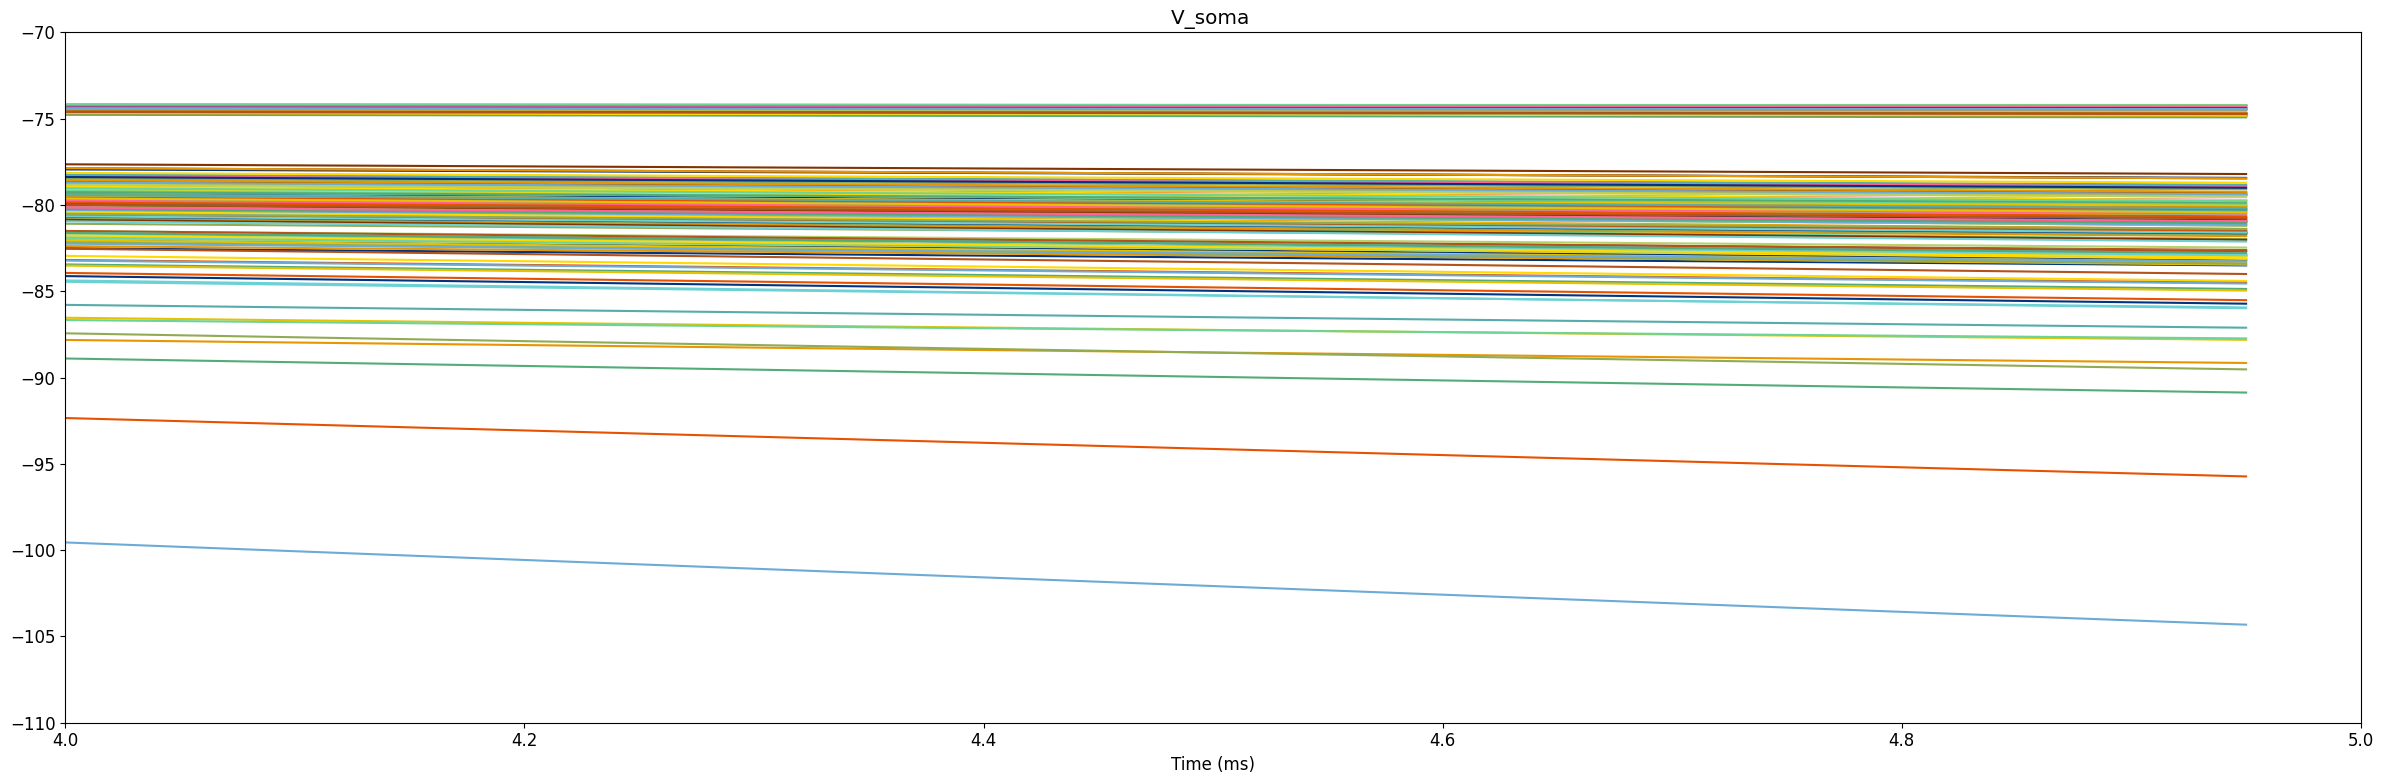

In [34]:
sim.analysis.plotTraces(timeRange=[4,5],figSize=(24,8), overlay=True, oneFigPer='trace', ylim=[-110,-70]);

In [35]:
# sim.analysis.plot2Dnet(showConns=True, figSize=(6, 6),fontSize=6);
# sim.analysis.plot2Dnet(showConns=True, figSize=(6, 6),fontSize=6, view = 'xz');

Plotting 3D cell shape ...


(<Figure size 3600x3600 with 2 Axes>, {})

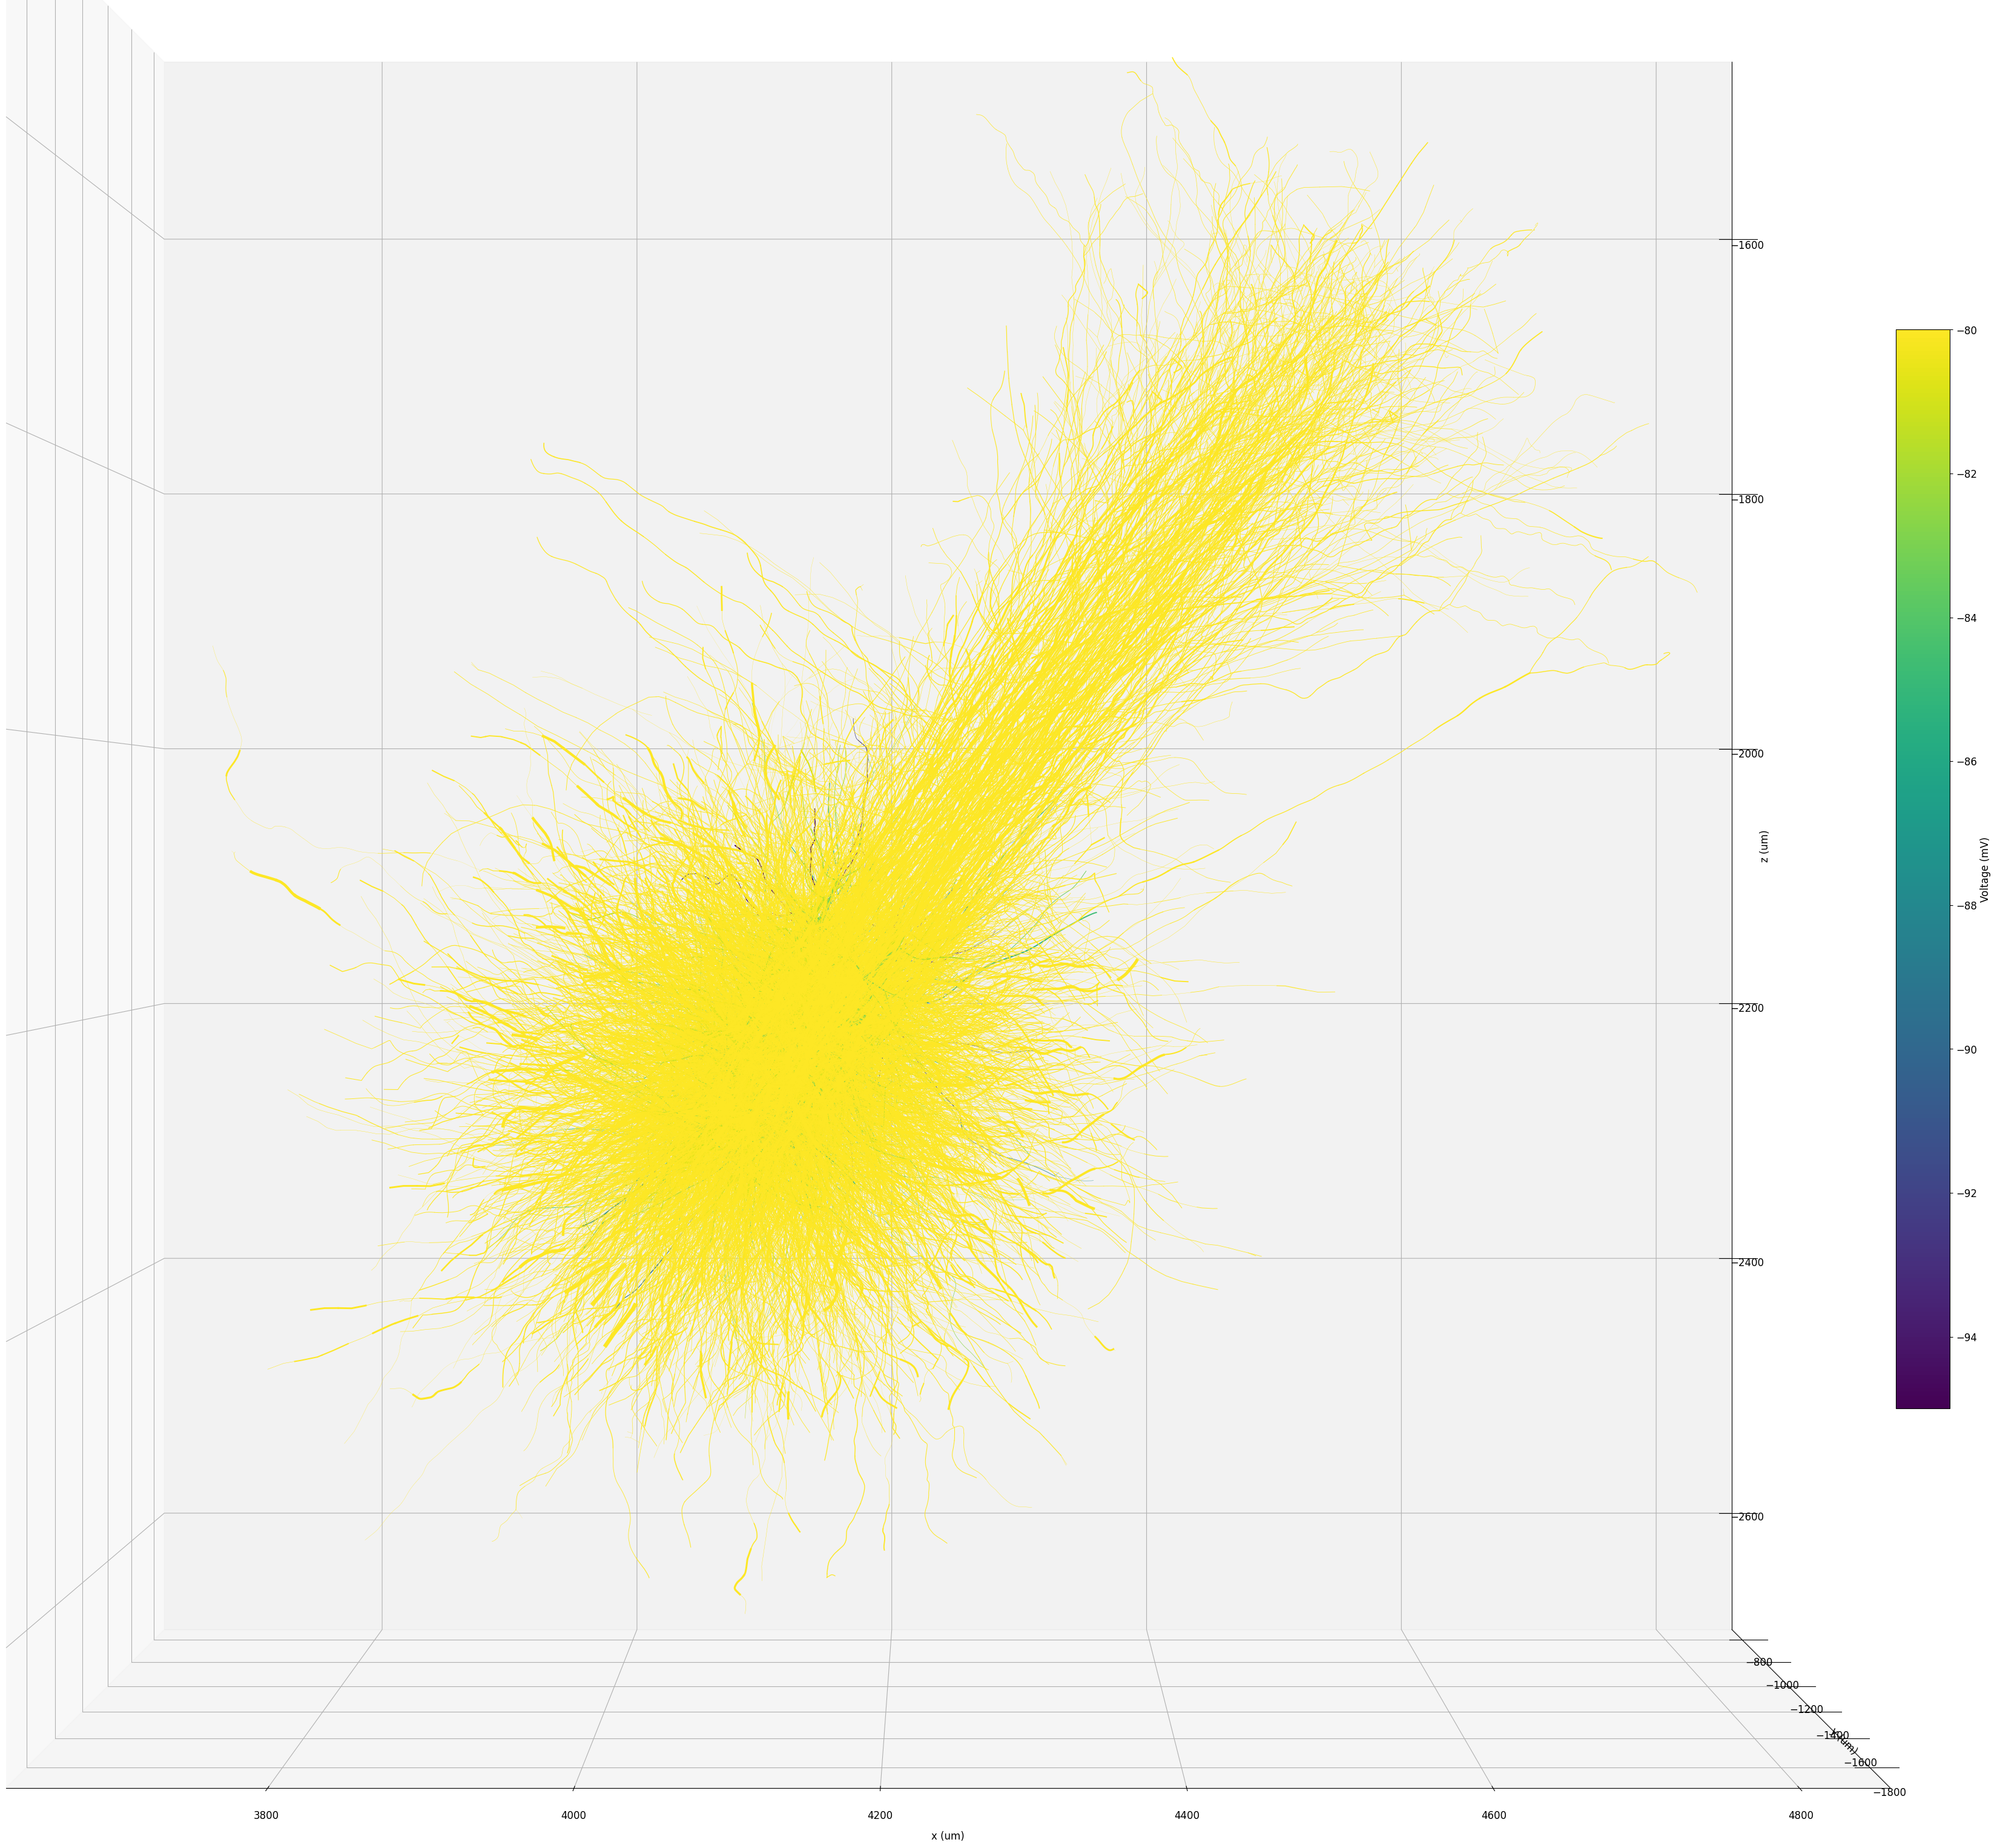

In [36]:
sim.analysis.plotShape(includePre= [ii for ii in range(0,len(node_gid))], includePost= [ii for ii in range(0,len(node_gid))], 
                       includeAxon=True, showSyns=True, showElectrodes=False,
    cvar= 'voltage', dist=0.6, elev=0, azim=-90, 
    axisLabels=True, synStyle='o', 
    clim= [-95.0, -80.0], showFig=False, synSize=12, saveFig=False, figSize=(36,36))

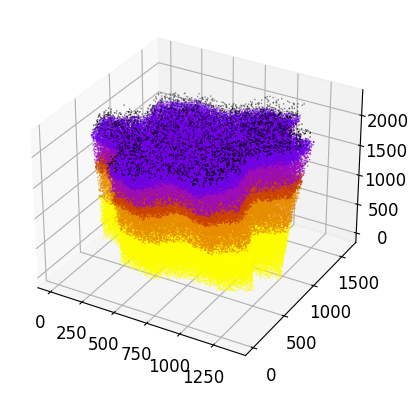

In [37]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(list(nodesinfo['x_new']),list(nodesinfo['y_new']),list(nodesinfo['z_new']), lw=0.05, s=1,
            c=[int(ii) for ii in list(nodesinfo['layer'])], cmap=plt.cm.get_cmap('gnuplot', 12))

Plotting 3D cell shape ...


(<Figure size 1200x1200 with 2 Axes>, {})

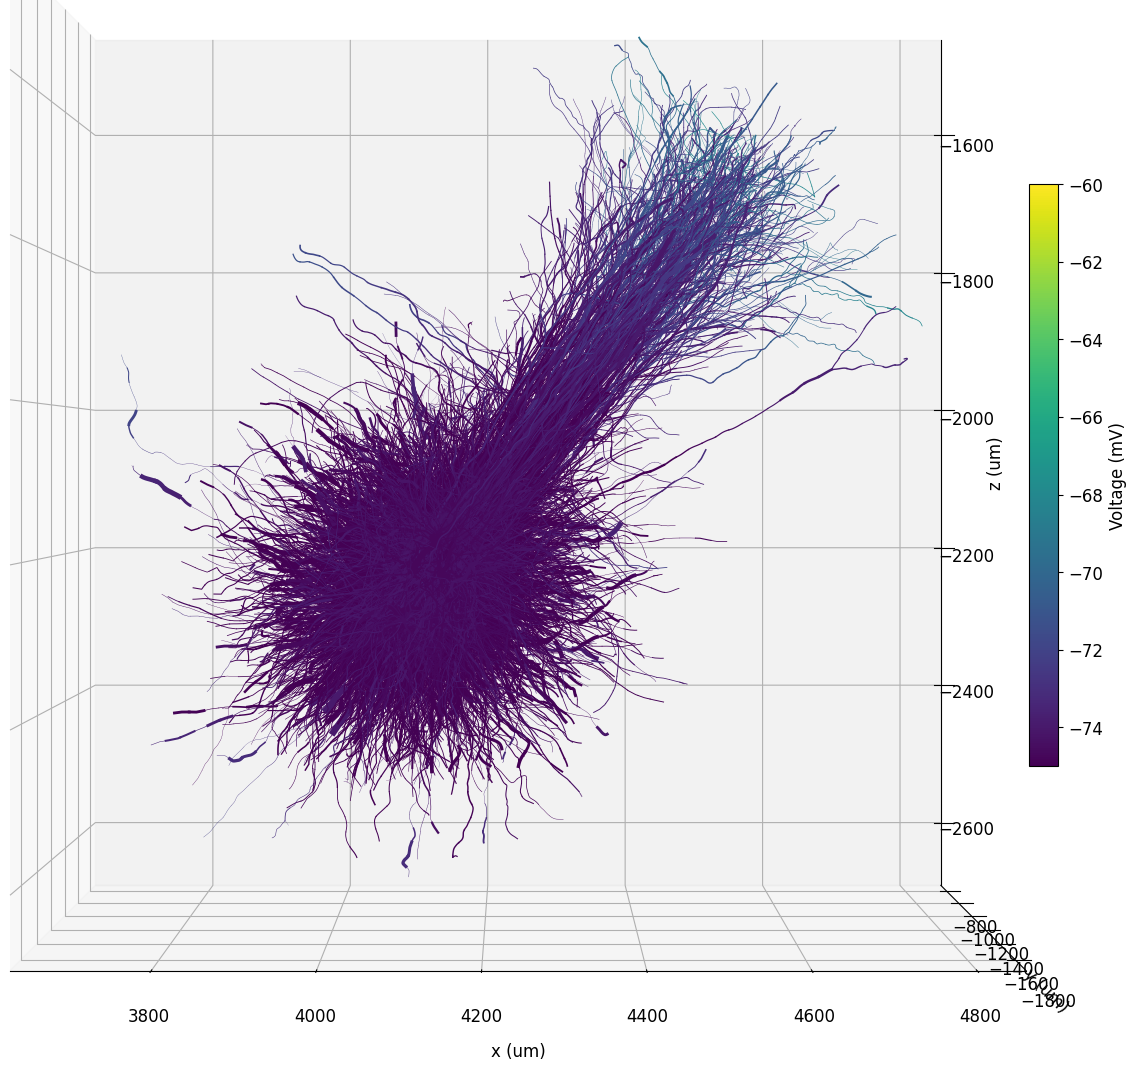

In [38]:
sim.analysis.plotShape(includePre= [ii for ii in range(len(node_gid))], includePost= [ii for ii in range(len(node_gid))], 
                       includeAxon=False, showSyns=True, showElectrodes=False,
    cvar= 'voltage', dist=0.6, elev=0, azim=-90, 
    axisLabels=True, synStyle='o', 
    clim= [-75.0, -60.0], showFig=False, synSize=4, saveFig=False, figSize=(12,12))

Plotting 3D cell shape ...


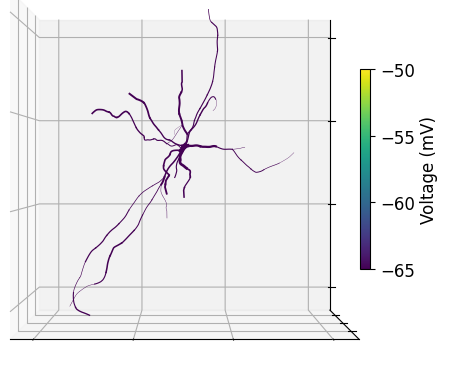

In [39]:
ii = 0
sim.analysis.plotShape(includePre= [ii], includePost= [ii], 
        includeAxon=False, showSyns=True, showElectrodes=False, 
            cvar= 'voltage', dist=0.6, elev=0, azim=-90, 
    axisLabels=False, synStyle='o', 
    clim= [-65.0, -50.0], showFig=False, synSize=4, saveFig=False, figSize=(4,4));

In [40]:
# for ii in range(len(node_gid)):
#     print(ii)
#     sim.analysis.plotShape(includePre= [ii], includePost= [ii], 
#         includeAxon=True, showSyns=True, showElectrodes=False,
#         cvar= 'voltage', dist=0.6, elev=0, azim=-90, 
#         axisLabels=True, synStyle='o', 
#         clim= [-80, -60], showFig=False, synSize=6, saveFig=True, figSize=(6,6))

In [41]:
def collect_pt3d(self, section):
        """        collect the pt3d info, for each section
        """
        n3dsec = 0
        r3dsec = np.zeros(3)
        for sec in [sec for secName, sec in self.secs.items() if section in secName]:
            sec['hObj'].push()
            n3d = int(neuron.h.n3d())  # get number of n3d points in each section
            # print("get number of n3d points in each section",n3d)
            r3d = np.zeros((3, n3d))  # to hold locations of 3D morphology for the current section
            n3dsec += n3d

            for i in range(n3d):
                r3dsec[0] += neuron.h.x3d(i)
                r3dsec[1] += neuron.h.y3d(i)
                r3dsec[2] += neuron.h.z3d(i)
            
            neuron.h.pop_section()

        r3dsec /= n3dsec
        
        return r3dsec
    
def getSecsPos(self, secList):
        """        Get Secs position
        """
        x3d, y3d, z3d = [], [], []
        
        for secName in secList:
            # print(secName)
            r3dsec = collect_pt3d(self, secName)
            # print(secName, r3dsec)
            
            x3d.append(r3dsec[0])
            y3d.append(r3dsec[1])
            z3d.append(r3dsec[2])
            
        return x3d, y3d, z3d
    
  
secPre = ['axon_32', 'axon_67', 'axon_72', 'axon_76', 'axon_79'] 
secPost = ['apic_47', 'apic_64', 'apic_47', 'apic_86', 'apic_86']

# secPre = ['axon_18', 'axon_32', 'axon_46', 'axon_62', 'axon_70', 'axon_70', 'axon_72'] 
# secPost = ['apic_20', 'apic_16', 'dend_4', 'apic_29', 'apic_30', 'apic_29', 'apic_2']

for ii in range(5):
    for c,metype in enumerate(sim.net.cells):
        if 'presyn' not in metype.tags['pop']:
            # print("\n", metype.tags)
            # secList = [secs for secs in metype.secs.keys() if "pt3d" in metype.secs[secs]['geom']]
            # secList = metype.secLists['all']
            if 'L2_TPC:B_cADpyr_S1F_0' in metype.tags['cellType']:
                secList = secPre[ii:ii+1]
                # print(np.mean(getSecsPos(metype,secList)[0]), np.mean(getSecsPos(metype,secList)[1]), np.mean(getSecsPos(metype,secList)[2]))
                preA = [np.mean(getSecsPos(metype,secList)[0]), np.mean(getSecsPos(metype,secList)[1]), np.mean(getSecsPos(metype,secList)[2])]
            elif 'L5_TPC:B_cADpyr_S1F_1' in metype.tags['cellType']:
                secList = secPost[ii:ii+1]
                # print(np.mean(getSecsPos(metype,secList)[0]), np.mean(getSecsPos(metype,secList)[1]), np.mean(getSecsPos(metype,secList)[2]))
                postA = [np.mean(getSecsPos(metype,secList)[0]), np.mean(getSecsPos(metype,secList)[1]), np.mean(getSecsPos(metype,secList)[2])]
                postPosition = [np.mean(getSecsPos(metype,metype.secLists['all'][0:1])[0]), np.mean(getSecsPos(metype,metype.secLists['all'][0:1])[1]), np.mean(getSecsPos(metype,metype.secLists['all'][0:1])[2])]
                
    print('L2_TPC:B_cADpyr_S1F_0 -> L5_TPC:B_cADpyr_S1F_1','\t\tdistance Syn\t\t',secPre[ii],secPost[ii],'\t d_um = ',np.sqrt(sum((np.array(preA) - np.array(postA))**2)))
    # print('distance Soma post',np.sqrt(sum((np.array(postPosition) - np.array(postA))**2)),'\t\tdistance Soma  pre',np.sqrt(sum((np.array(preA) - np.array(postPosition))**2)))
    # print()


NameError: name 'preA' is not defined

In [ ]:
# netParams.connParams['L2_TPC:B_cADpyr_S1F_0->L5_TPC:B_cADpyr_S1F_1']
cellName_list[gid], cellName_list[gid2]

('L2_TPC:B_cADpyr_S1F_0', 'L5_TPC:C_cADpyr_S1F_0')

In [ ]:
for gid in sorted(cellName_list.keys()):
    for gid2 in sorted(cellName_list.keys()):

        var_list_a = ['@source_node', 'afferent_center_x', 'afferent_center_y', 'afferent_center_z', 'afferent_section_id', 'afferent_section_pos', 'afferent_section_type', 'afferent_segment_id', 
                    'afferent_segment_offset', 'afferent_surface_x', 'afferent_surface_y', 'afferent_surface_z', '@target_node', 'efferent_center_x', 'efferent_center_y', 'efferent_center_z', 
                    'efferent_section_id', 'efferent_section_pos', 'efferent_section_type', 'efferent_segment_id', 'efferent_segment_offset', 'efferent_surface_x', 'efferent_surface_y', 
                    'efferent_surface_z', 'spine_length', 'syn_property_rule', 'syn_type_id']
        # afferent edges of node_ids[gid2]
        sampled_edge_ids = conn.afferent_edges(gid2)    
        # var_list_a = sorted(conn.property_names)[0:12]    
        var_list_a =  ['@source_node', 'afferent_center_x', 'afferent_center_y', 'afferent_center_z', 
                    'afferent_section_pos', 'afferent_section_type', 'afferent_segment_id',
                    'afferent_section_id', 
                    'afferent_segment_offset',
                    # '@target_node', 'efferent_center_x', 'efferent_center_y', 'efferent_center_z', 
                    #   'efferent_section_id',     
                    #   'efferent_segment_offset', 
                    #   'spine_length', 'syn_property_rule', 'syn_type_id'
                    ]
        connsinfo = conn.get(sampled_edge_ids,var_list_a)

        if len(connsinfo.get(connsinfo['@source_node']==gid)) >= 20:
            print(gid,cellName_list[gid], cellName_list[gid2],gid2,len(connsinfo.get(connsinfo['@source_node']==gid)))
            print(netParams.connParams[cellName_list[gid]+'->'+cellName_list[gid2]])

133426 L4_TPC_cADpyr_S1F_3 L5_LBC_cSTUT_S1F_0 173539 20
{'preConds': {'pop': 'L4_TPC_cADpyr_S1F_3'}, 'postConds': {'pop': 'L5_LBC_cSTUT_S1F_0'}, 'connList': [[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0]], 'sec': ['soma_0', 'soma_0', 'soma_0', 'soma_0', 'dend_14', 'dend_17', 'dend_2', 'dend_2', 'dend_58', 'dend_60', 'soma_0', 'soma_0', 'soma_0', 'soma_0', 'dend_29', 'dend_29', 'dend_14', 'dend_6', 'dend_46', 'dend_76'], 'synMech': 'L4_TPC_cADpyr_S1F_3->L5_LBC_cSTUT_S1F_0', 'weight': [0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391, 0.8454380035400391

In [ ]:
gid = 133426
gid2 = 173539

var_list_a = ['@source_node', 'afferent_center_x', 'afferent_center_y', 'afferent_center_z', 'afferent_section_id', 'afferent_section_pos', 'afferent_section_type', 'afferent_segment_id', 
              'afferent_segment_offset', 'afferent_surface_x', 'afferent_surface_y', 'afferent_surface_z', '@target_node', 'efferent_center_x', 'efferent_center_y', 'efferent_center_z', 
              'efferent_section_id', 'efferent_section_pos', 'efferent_section_type', 'efferent_segment_id', 'efferent_segment_offset', 'efferent_surface_x', 'efferent_surface_y', 
              'efferent_surface_z', 'spine_length', 'syn_property_rule', 'syn_type_id']
# afferent edges of node_ids[gid2]
sampled_edge_ids = conn.afferent_edges(gid2)    
# var_list_a = sorted(conn.property_names)[0:12]    
var_list_a =  ['@source_node', 'afferent_center_x', 'afferent_center_y', 'afferent_center_z', 
               'afferent_section_pos', 'afferent_section_type', 'afferent_segment_id',
               'afferent_section_id', 
              'afferent_segment_offset',
              # '@target_node', 'efferent_center_x', 'efferent_center_y', 'efferent_center_z', 
            #   'efferent_section_id',     
            #   'efferent_segment_offset', 
            #   'spine_length', 'syn_property_rule', 'syn_type_id'
              ]
connsinfo = conn.get(sampled_edge_ids,var_list_a)
connsinfo.get(connsinfo['@source_node']==gid)

,@source_node,afferent_center_x,afferent_center_y,afferent_center_z,afferent_section_pos,afferent_section_type,afferent_segment_id,afferent_section_id,afferent_segment_offset
263064425,133426,4062.779785,-1271.787598,-2302.896729,0.000000,1,0,0,0.000000
263064426,133426,4062.779785,-1271.787598,-2302.896729,0.000000,1,0,0,0.000000
263064427,133426,4062.779785,-1271.787598,-2302.896729,0.000000,1,0,0,0.000000
263064428,133426,4062.779785,-1271.787598,-2302.896729,0.000000,1,0,0,0.000000
263064429,133426,4071.660889,-1257.241211,-2296.092529,0.025781,3,1,568,3.196558
263064430,133426,4074.372314,-1261.409424,-2287.995605,0.118295,3,2,571,0.712395
263064431,133426,4037.545654,-1267.621704,-2374.852051,0.975359,3,13,556,1.965854
263064432,133426,4039.432129,-1268.613892,-2370.221436,0.860188,3,11,556,2.889856
263064433,133426,4048.866211,-1249.099121,-2368.468018,0.175776,3,11,612,0.661954
263064434,133426,4076.100830,-1248.420410,-2318.894775,0.123909,3,7,614,3.008288


In [ ]:
# print(np.array(preA) + np.array([3000.0, -2000.0, -3500.0]), np.array(postA) + np.array([3000.0, -2000.0, -3500.0]))
# cellName_list, netParams.cellParams['L2_TPC:B_cADpyr_S1F_0']['secs']['apic_20']['geom']
# cellName_list